# ANN - Dự báo chất lượng xe ô tô (Car Evaluation)
**Dataset:** UCI Car Evaluation Dataset  
**Mục tiêu:** Phân loại chất lượng xe vào 4 nhãn: `unacc`, `acc`, `good`, `vgood`  
**Mô hình:** Artificial Neural Network (ANN) dùng Keras/TensorFlow


In [ ]:
# Cell 1: Cài đặt thư viện cần thiết
# ucimlrepo: thư viện chính thức để tải dataset từ UCI
# tensorflow/keras: xây dựng và huấn luyện mô hình ANN
# scikit-learn: tiền xử lý dữ liệu và đánh giá mô hình

!pip install ucimlrepo tensorflow scikit-learn pandas numpy matplotlib seaborn -q
print("Cài đặt hoàn tất!")


Cài đặt hoàn tất!


In [ ]:
# Cell 2: Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo          # tải dataset từ UCI

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Đặt seed để kết quả tái lập được (reproducible)
np.random.seed(42)
tf.random.set_seed(42)

print("Import thành công!")
print(f"TensorFlow version: {tf.__version__}")


Import thành công!
TensorFlow version: 2.20.0


## 1. Tải và Khám phá Dữ liệu

In [ ]:
# Cell 3: Tải dataset Car Evaluation từ UCI (id=19)
# Dữ liệu gồm 1728 mẫu, 6 thuộc tính đầu vào, 1 nhãn đầu ra

car_evaluation = fetch_ucirepo(id=19)

X = car_evaluation.data.features   # 6 cột đặc trưng (features)
y = car_evaluation.data.targets    # 1 cột nhãn (label)

print("Kích thước X (features):", X.shape)
print("Kích thước y (labels)  :", y.shape)
print()
print("5 dòng đầu của X:")
X.head()


Kích thước X (features): (1728, 6)
Kích thước y (labels)  : (1728, 1)

5 dòng đầu của X:


,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med


In [ ]:
# Cell 4: Xem thông tin tổng quát về dữ liệu
# Tất cả cột đều là kiểu object (categorical - dữ liệu phân loại dạng chữ)
# => cần mã hóa thành số trước khi đưa vào ANN

print("Thông tin dataset:")
X.info()
print()
print("Các giá trị có thể có của từng cột:")
for col in X.columns:
    print(f"  {col}: {X[col].unique()}")


Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
dtypes: object(6)
memory usage: 81.1+ KB

Các giá trị có thể có của từng cột:
  buying: ['vhigh' 'high' 'med' 'low']
  maint: ['vhigh' 'high' 'med' 'low']
  doors: ['2' '3' '4' '5more']
  persons: ['2' '4' 'more']
  lug_boot: ['small' 'med' 'big']
  safety: ['low' 'med' 'high']


Phân phối nhãn:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64



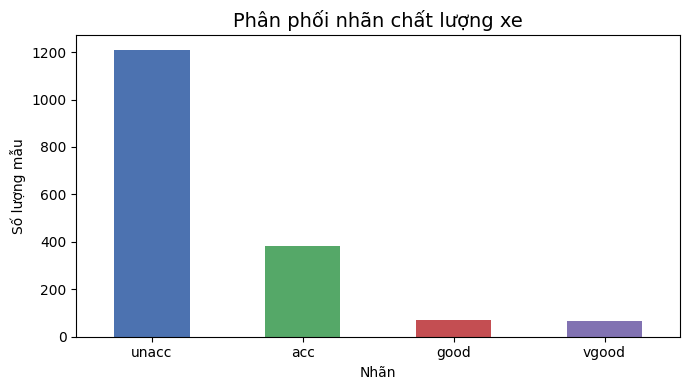

In [ ]:
# Cell 5: Kiểm tra phân phối nhãn (label distribution)
# Quan trọng: nếu nhãn mất cân bằng (imbalanced), model dễ bias sang nhãn đa số

print("Phân phối nhãn:")
label_counts = y.iloc[:, 0].value_counts()
print(label_counts)
print()

# Vẽ biểu đồ phân phối
plt.figure(figsize=(7, 4))
label_counts.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.title("Phân phối nhãn chất lượng xe", fontsize=14)
plt.xlabel("Nhãn")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Tiền xử lý Dữ liệu (Preprocessing)

ANN chỉ hiểu được số, không hiểu chữ. Vì vậy phải **mã hóa (encode)** tất cả các cột dạng chữ thành số.

Ta dùng **One-Hot Encoding** cho features (vì các giá trị không có thứ tự rõ ràng như `small/med/big` không hẳn có khoảng cách đều nhau) và **Label Encoding** cho nhãn đầu ra.


In [ ]:
# Cell 6: One-Hot Encoding cho features (X)
# One-Hot: mỗi giá trị dạng chữ được chuyển thành một cột nhị phân (0/1)
# Ví dụ: buying=[vhigh, high, med, low] => 4 cột buying_vhigh, buying_high, ...

X_encoded = pd.get_dummies(X)

print("Shape sau khi One-Hot Encoding:", X_encoded.shape)
print("Các cột sau encoding:")
print(list(X_encoded.columns))


Shape sau khi One-Hot Encoding: (1728, 21)
Các cột sau encoding:
['buying_high', 'buying_low', 'buying_med', 'buying_vhigh', 'maint_high', 'maint_low', 'maint_med', 'maint_vhigh', 'doors_2', 'doors_3', 'doors_4', 'doors_5more', 'persons_2', 'persons_4', 'persons_more', 'lug_boot_big', 'lug_boot_med', 'lug_boot_small', 'safety_high', 'safety_low', 'safety_med']


In [ ]:
# Cell 7: Label Encoding cho nhãn y
# Chuyển nhãn chữ thành số nguyên:
#   unacc=?, acc=?, good=?, vgood=?  (thứ tự do LabelEncoder quyết định)

le = LabelEncoder()
y_encoded = le.fit_transform(y.iloc[:, 0])  # chuyển cột nhãn thành mảng số

print("Các nhãn và mã số tương ứng:")
for idx, cls in enumerate(le.classes_):
    print(f"  {cls} => {idx}")

print()
print("5 phần tử đầu của y_encoded:", y_encoded[:5])


Các nhãn và mã số tương ứng:
  acc => 0
  good => 1
  unacc => 2
  vgood => 3

5 phần tử đầu của y_encoded: [2 2 2 2 2]


## 3. Chia Tập Huấn luyện và Kiểm tra

In [ ]:
# Cell 8: Chia dữ liệu thành train (80%) và test (20%)
# stratify=y_encoded: đảm bảo tỉ lệ các nhãn trong train và test giống nhau
# Điều này quan trọng vì dataset có mất cân bằng nhãn (unacc chiếm đa số)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # giữ nguyên tỉ lệ phân phối nhãn
)

print(f"Tập train: {X_train.shape[0]} mẫu")
print(f"Tập test : {X_test.shape[0]} mẫu")


Tập train: 1382 mẫu
Tập test : 346 mẫu


## 4. Xây dựng Mô hình ANN

Kiến trúc mạng:
- **Input layer**: kích thước bằng số features sau encoding
- **Hidden layer 1**: 64 neurons, activation = ReLU
- **Hidden layer 2**: 32 neurons, activation = ReLU  
- **Dropout**: tránh overfitting (bỏ ngẫu nhiên 30% neurons khi training)
- **Output layer**: 4 neurons (4 nhãn), activation = Softmax


In [ ]:
# Cell 9: Xây dựng kiến trúc ANN bằng Keras Sequential API
# Sequential: các layer xếp tuần tự từ input đến output

num_features = X_train.shape[1]   # số cột đầu vào
num_classes  = len(le.classes_)   # số nhãn đầu ra = 4

model = keras.Sequential([
    # Lớp đầu vào + Hidden layer 1
    # Dense: mỗi neuron kết nối đầy đủ với tất cả neuron lớp trước (fully connected)
    # activation='relu': hàm kích hoạt ReLU, giúp model học phi tuyến
    layers.Dense(64, activation='relu', input_shape=(num_features,)),

    # Dropout: trong mỗi bước training, tắt ngẫu nhiên 30% neurons
    # => giảm overfitting (model không phụ thuộc quá nhiều vào một vài neuron)
    layers.Dropout(0.3),

    # Hidden layer 2: ít neurons hơn, tiếp tục trích xuất đặc trưng
    layers.Dense(32, activation='relu'),

    layers.Dropout(0.2),

    # Output layer: 4 neurons ứng với 4 nhãn
    # activation='softmax': chuyển đầu ra thành xác suất, tổng = 1
    layers.Dense(num_classes, activation='softmax')
])

model.summary()   # In tóm tắt kiến trúc mô hình


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,620 (14.14 KB)

 Trainable params: 3,620 (14.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 10: Compile mô hình — cấu hình quá trình học
# optimizer='adam': thuật toán tối ưu phổ biến, tự điều chỉnh learning rate
# loss='sparse_categorical_crossentropy': hàm mất mát cho bài toán phân loại nhiều nhãn
#   (dùng 'sparse_' vì nhãn y là số nguyên, không phải one-hot)
# metrics=['accuracy']: theo dõi độ chính xác trong quá trình training

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Compile thành công!")


Compile thành công!


## 5. Huấn luyện Mô hình

In [ ]:
# Cell 11: Huấn luyện mô hình
# epochs=100: duyệt qua toàn bộ tập train 100 lần
# batch_size=32: mỗi lần cập nhật trọng số dùng 32 mẫu
# validation_split=0.1: trích 10% từ tập train để theo dõi val_loss
# EarlyStopping: tự dừng nếu val_loss không cải thiện sau 15 epochs
#   => tránh training quá lâu và tránh overfitting

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',    # theo dõi validation loss
    patience=15,           # chờ 15 epochs trước khi dừng
    restore_best_weights=True  # khôi phục trọng số tốt nhất
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1    # hiện tiến trình mỗi epoch
)

print(f"\nDừng tại epoch: {len(history.history['loss'])}")


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5857 - loss: 1.1211 - val_accuracy: 0.6763 - val_loss: 0.8748
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7136 - loss: 0.7902 - val_accuracy: 0.6906 - val_loss: 0.6482
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7731 - loss: 0.5931 - val_accuracy: 0.8489 - val_loss: 0.4854
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8158 - loss: 0.4724 - val_accuracy: 0.8561 - val_loss: 0.4044
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8286 - loss: 0.4075 - val_accuracy: 0.8705 - val_loss: 0.3539
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8335 - loss: 0.3848 - val_accuracy: 0.8705 - val_loss: 0.3283
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8455 - loss: 0.3636 - val_accuracy: 0.8777 - val_loss: 0.2976
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8552 - loss: 0.3250 - val_accuracy: 0.8993 - 

## 6. Trực quan hóa Quá trình Huấn luyện

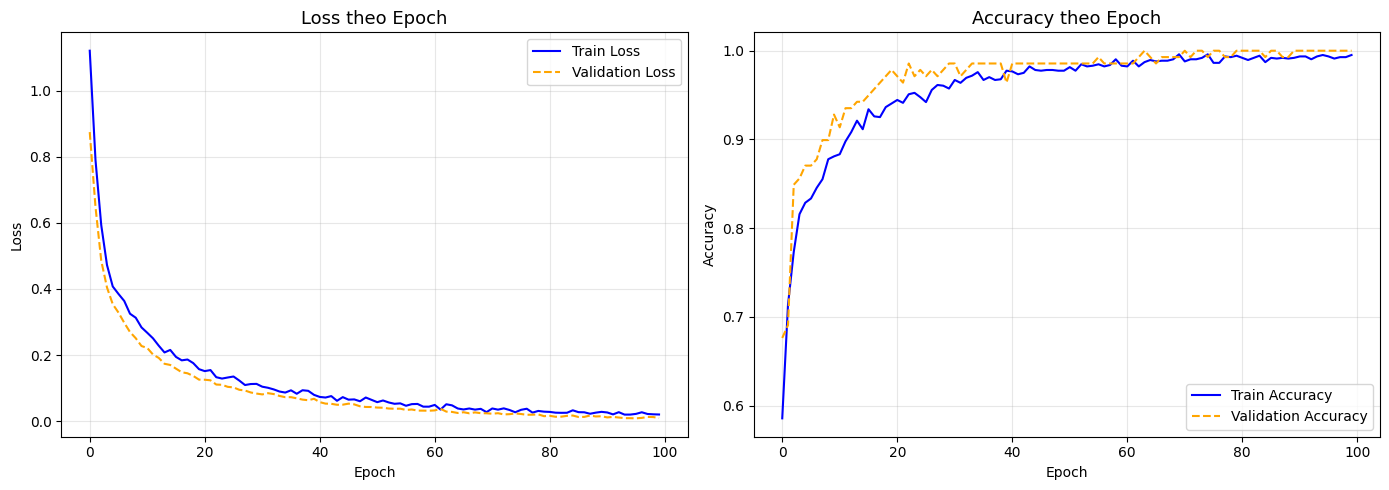

In [ ]:
# Cell 12: Vẽ đồ thị Loss và Accuracy theo từng epoch
# Dùng để kiểm tra: model có học tốt không? Có bị overfitting không?
# Overfitting dấu hiệu: train_acc tăng nhưng val_acc giảm hoặc không tăng

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị Loss
ax1.plot(history.history['loss'],     label='Train Loss',      color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
ax1.set_title('Loss theo Epoch', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Đồ thị Accuracy
ax2.plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
ax2.set_title('Accuracy theo Epoch', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Đánh giá Mô hình trên Tập Test

In [ ]:
# Cell 13: Đánh giá mô hình trên tập test (dữ liệu chưa thấy bao giờ)
# Đây là kết quả thực sự phản ánh khả năng tổng quát hóa của model

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


Test Loss    : 0.0060
Test Accuracy: 1.0000 (100.00%)


In [ ]:
# Cell 14: Dự đoán nhãn cho tập test
# model.predict() trả về xác suất cho từng nhãn (shape: [n_samples, 4])
# np.argmax: lấy chỉ số có xác suất cao nhất => đó là nhãn dự đoán

y_pred_prob = model.predict(X_test)           # xác suất từng nhãn
y_pred      = np.argmax(y_pred_prob, axis=1)  # nhãn dự đoán (số)

print("Ví dụ xác suất dự đoán cho 3 mẫu đầu:")
for i in range(3):
    probs = {le.classes_[j]: f"{y_pred_prob[i][j]:.3f}" for j in range(num_classes)}
    print(f"  Mẫu {i+1}: {probs}  => Dự đoán: {le.classes_[y_pred[i]]}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Ví dụ xác suất dự đoán cho 3 mẫu đầu:
  Mẫu 1: {'acc': '0.011', 'good': '0.989', 'unacc': '0.000', 'vgood': '0.000'}  => Dự đoán: good
  Mẫu 2: {'acc': '0.000', 'good': '0.000', 'unacc': '1.000', 'vgood': '0.000'}  => Dự đoán: unacc
  Mẫu 3: {'acc': '0.000', 'good': '0.000', 'unacc': '1.000', 'vgood': '0.000'}  => Dự đoán: unacc


In [ ]:
# Cell 15: Classification Report — báo cáo chi tiết từng nhãn
# Precision: trong các lần dự đoán là X, bao nhiêu % đúng thật
# Recall   : trong các mẫu thật là X, model tìm đúng bao nhiêu %
# F1-score : trung bình điều hòa của Precision và Recall

print("=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_   # hiện tên nhãn thay vì số
))


=== Classification Report ===
              precision    recall  f1-score   support

         acc       1.00      1.00      1.00        77
        good       1.00      1.00      1.00        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      1.00      1.00        13

    accuracy                           1.00       346
   macro avg       1.00      1.00      1.00       346
weighted avg       1.00      1.00      1.00       346



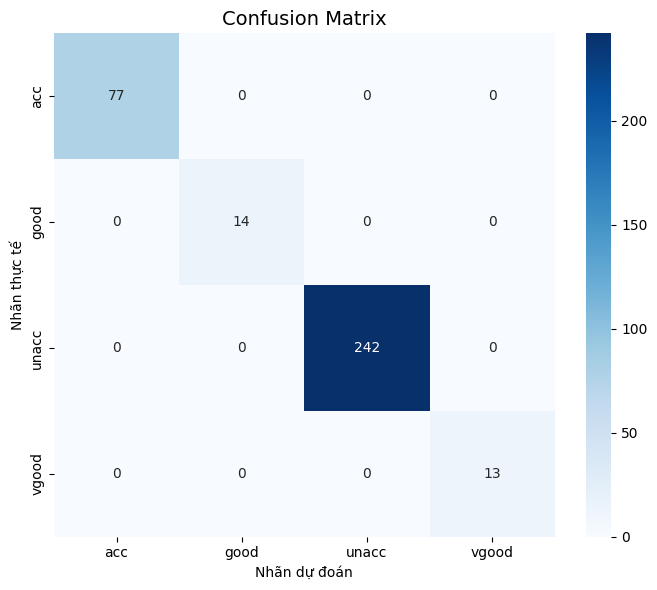

In [ ]:
# Cell 16: Confusion Matrix — ma trận nhầm lẫn
# Hàng: nhãn thực tế | Cột: nhãn dự đoán
# Ô chéo chính: dự đoán đúng | Ô khác: dự đoán sai
# Giúp xác định model hay nhầm nhãn nào với nhãn nào

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,          # hiện số trong từng ô
    fmt='d',             # định dạng số nguyên
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.tight_layout()
plt.show()


## 8. Dự đoán với Dữ liệu Mới

In [ ]:
import pandas as pd
import numpy as np
# Cell 17: Dự đoán chất lượng xe với 1 mẫu dữ liệu mới
# Mẫu ví dụ: xe giá thấp, bảo trì thấp, 4 cửa, chở được nhiều người,
#            khoang hành lý lớn, độ an toàn cao => kỳ vọng nhãn: vgood hoặc good

sample = pd.DataFrame([
    {
    'buying'  : 'low',
    'maint'   : 'low',
    'doors'   : '4',
    'persons' : 'more',
    'lug_boot': 'big',
    'safety'  : 'high'
}])

# Phải mã hóa mẫu mới theo đúng cấu trúc đã encode lúc training
sample_encoded = pd.get_dummies(sample)

# Căn chỉnh cột: mẫu mới phải có đúng các cột như tập train
# Cột thiếu sẽ được điền 0, cột thừa sẽ bị bỏ
sample_encoded = sample_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Chuyển đổi tất cả các cột sang kiểu int để đảm bảo tính đồng nhất cho TensorFlow
sample_encoded = sample_encoded.astype(int)

# Dự đoán
pred_prob  = model.predict(sample_encoded, verbose=0)
pred_label = le.classes_[np.argmax(pred_prob)]

print("Thông tin xe:")
print(sample.to_string(index=False))
print()
print("Xác suất từng nhãn:")
for cls, prob in zip(le.classes_, pred_prob[0]):
    bar = '█' * int(prob * 30)
    print(f"  {cls:7s}: {prob:.4f}  {bar}")
print()
print(f"=> Kết quả dự đoán: [{pred_label.upper()}]")

Thông tin xe:
buying maint doors persons lug_boot safety
   low   low     4    more      big   high

Xác suất từng nhãn:
  acc    : 0.0000  
  good   : 0.0010  
  unacc  : 0.0000  
  vgood  : 0.9990  █████████████████████████████

=> Kết quả dự đoán: [VGOOD]


## 9. Tóm tắt Pipeline

```
Dữ liệu thô (chữ)
    ↓ One-Hot Encoding (features)  +  Label Encoding (nhãn)
Dữ liệu số
    ↓ Train/Test split (80/20, stratified)
Tập train / Tập test
    ↓ ANN: Dense(64,relu) → Dropout(0.3) → Dense(32,relu) → Dropout(0.2) → Dense(4,softmax)
    ↓ Compile: Adam optimizer + Sparse Categorical Crossentropy
    ↓ Fit: 100 epochs, batch=32, EarlyStopping(patience=15)
Mô hình đã huấn luyện
    ↓ Đánh giá: Accuracy, Classification Report, Confusion Matrix
Kết quả
```

**Các điểm cần ghi nhớ:**
- Dữ liệu category phải encode trước khi đưa vào ANN
- Dropout giúp giảm overfitting
- EarlyStopping tiết kiệm thời gian và tránh training quá mức
- `softmax` ở output cho bài toán phân loại nhiều nhãn
